# Regional lead-time ACC skill

A cache-first regional ACC/nRMSE diagnostic. Seasonal and monthly gridded skill products are reduced to area-weighted regional curves; missing monthly products can be created through direct realm-specific builder callables.


## Diagnostic definition

Each curve is an area-weighted mean of a **gridded skill metric**, not a metric recomputed from spatially averaged anomalies. Supported regions are Global, Land, Ocean, Tropics, NH/SH Extratropics, CONUS, North America, and Eurasia. Land and ocean use the Natural Earth mask. Ocean fields (`SST`, `SSS`, `OHC700`) omit the Land region and land fields (`H2OSNO`, `H2OSOI`, `TWS`) omit the Ocean region: on the 5° grid either mask keeps only a few coastal cells for them.

nRMSE is RMSE divided by the observed standard deviation, so the regional nRMSE curves leave out grid cells whose observed standard deviation is below 1% of the field's median (e.g. HadISST SST held at the freezing point under sea ice), which would otherwise dominate the area mean. ACC uses every valid cell.

Monthly ALL-init skill caches are built by `build_atm_monthly_cache` (atmosphere), `build_ocn_monthly_cache` (`OCN_MONTHLY_REFERENCES`), or `build_lnd_monthly_cache` (`LND_MONTHLY_REFERENCES`).


In [31]:
import importlib
import sys
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from functools import partial
from IPython.display import display


project_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'workflows').is_dir())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from esp_lab.utils import mov_utils as mov
from esp_lab import env_paths
from esp_lab.utils.netcdf_utils import load_netcdf
from esp_lab.paths import leadtime_acc_dir
from esp_lab.utils.unit_conversion import (
    convert_kelvin_to_celsius, convert_mpas_ohc_to_jm2, convert_pa_to_hpa,
    convert_precip_mps_to_mmday, no_unit_conversion,
)
from esp_lab.utils.dask_util import DaskConfig, get_cluster_client
regional_acc_module = importlib.import_module('workflows.leadtime_skill.regional_acc')
regional_acc_skill_plot_module = importlib.import_module(
    'workflows.leadtime_skill.regional_acc_skill_plot'
)
monthly_skill_module = importlib.import_module('workflows.leadtime_skill.monthly_skill')

# Reload local reusable code so notebook reruns pick up package edits.
regional_acc_module = importlib.reload(regional_acc_module)
regional_acc_skill_plot_module = importlib.reload(regional_acc_skill_plot_module)
monthly_skill_module = importlib.reload(monthly_skill_module)
regional_skill_metrics = regional_acc_module.regional_skill_metrics
plot_regional_acc_skill_template = regional_acc_skill_plot_module.plot_regional_acc_skill_template
build_atmospheric_monthly_skill_caches = monthly_skill_module.build_atmospheric_monthly_skill_caches
build_land_monthly_skill_caches = monthly_skill_module.build_land_monthly_skill_caches



### Create Dask Cluster

Monthly cache rebuilds (`MONTHLY_CACHE_MODE='auto'`/`'rebuild'`) read and regrid raw ensemble archives, so they benefit from the same distributed cluster used by the 1a ACC notebooks. Cache-only runs (all skill products already exist) still work fine with `machine_env="none"`.

In [32]:
import dask
from dask.distributed import wait, get_client
from esp_lab.utils.notebook_resources import restart_notebook_cluster, close_notebook_resources

dask.__version__

# User-adjustable Dask settings (shared login nodes are capped at four workers).
machine_env = "local"
dask_workers = 12

dask_cfg = DaskConfig(cluster_type=machine_env, workers=dask_workers)
cluster, client, workflow_resources = restart_notebook_cluster(
    globals(), lambda: get_cluster_client(dask_cfg)
)

cluster


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
This can easily exceed memory/CPU limits and crash your Jupyter kernel.
We highly recommend launching Jupyter on an Exclusive Perlmutter Compute Node.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


Scheduler: tcp://127.0.0.1:44317
Connected workers: 4
Dashboard: http://127.0.0.1:36625/status


LocalCluster(61cde9b0, 'tcp://127.0.0.1:44317', workers=4, threads=4, memory=14.90 GiB)

In [33]:

FIELD = 'TWS' # Total Water Storage, unit mm
#FIELD = 'H2OSNO' # Snow Water Equivalent, unit mm
#FIELD = 'PRECT' # Precipitation, unit mm/day
#FIELD = 'TS' # Surface Temperature, unit degC
#FIELD = 'TREFHT' # Near-Surface Air Temperature, unit degC
#FIELD = 'PSL' # Sea Level Pressure, unit hPa
#FIELD = 'SST' # Sea Surface Temperature, unit degC
#FIELD = 'SSS' # Sea Surface Salinity, unit psu
#FIELD = 'OHC700' # Ocean Heat Content (0-700m), unit J/m^2

# mode for derivation of variables choices (monthly ALL-init skill caches; seasonal skill maps come from 1a):
# "auto": automatically determine whether to rebuild or use cached results
# "rebuild": force recomputation
# "require": require cached results and fail if not available
derivation_mode = "auto"

# True to force recomputation of the monthly skill caches this notebook owns, False to use cached results if available
recompute_skill = False

YEAR_END = 2011

S2D_DIAG_ROOT = env_paths.s2d_diag_root()
RAW_MODEL_ROOT = env_paths.raw_model_root()
OBSERVATION_ROOT = Path(str(env_paths.obs_root()))
FIGURE_OUTDIR = env_paths.figure_root()
FIGURE_OUTDIR.mkdir(parents=True, exist_ok=True)

# False: reuse valid saved 1a ACC products. Missing or unreadable
# requested products trigger the relevant producer automatically.
# True: rebuild the requested producer skill diagnostics even if every
# cache exists, then reload the newly written NetCDF products.
FORCE_RECOMPUTE = recompute_skill

# Monthly cache controls for the ALL-init row: require, auto, or rebuild.
MONTHLY_CACHE_MODE = derivation_mode
MONTHLY_CACHE_STAGE = 'skill_monthly'

# One dictionary controls every supported variable: its producer realm,
# label, default standardized regions, and ACC/nRMSE plotting ranges.
# Available fields. Keep this configuration in the driver so a user can
# adjust source tags, default regions, or y ranges without editing modules.
E3SM_SOURCE_TAGS = {
    'E3SMv3-FOSIRL': 'JRA55_FOSIRL',
    'E3SMv3-Reanalysis': 'Reanalysis',
    'E3SMv3-4DEnVarOcn': '4DEnVarOcn',
}

# Raw-data contracts used only when an independent monthly cache must be built.
# These are driver inputs; reusable modules contain no experiment paths/setup.
E3SM_CASES = {
    'FOSIRL': {
        'cache_tag': 'JRA55_FOSIRL',
        'case_prefix': 'WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL',
    },
    'Reanalysis': {
        'cache_tag': 'Reanalysis',
        'case_prefix': 'WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce',
    },
    '4DEnVarOcn': {
        'cache_tag': '4DEnVarOcn',
        'case_prefix': 'WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_4DEnVarOcn',
    },
}

ATM_MONTHLY_VARIABLES = {
    'TREFHT': {
        'obs_product': 'ERA5', 'obs_variable': 'tas',
        'obs_year_start': 1979, 'obs_year_end': 2019,
        'model_convert': convert_kelvin_to_celsius,
        'obs_convert': convert_kelvin_to_celsius,
    },
    'TS': {
        'obs_product': 'ERA5', 'obs_variable': 'ts',
        'obs_year_start': 1979, 'obs_year_end': 2019,
        'model_convert': convert_kelvin_to_celsius,
        'obs_convert': convert_kelvin_to_celsius,
    },
    'PRECT': {
        'obs_product': 'GPCP_v2.3', 'obs_variable': 'PRECT',
        'obs_year_start': 1979, 'obs_year_end': 2017,
        'model_convert': convert_precip_mps_to_mmday,
        'obs_convert': partial(no_unit_conversion, units='mm/day'),
    },
    'PSL': {
        'obs_product': 'ERA5', 'obs_variable': 'psl',
        'obs_year_start': 1979, 'obs_year_end': 2019,
        'model_convert': convert_pa_to_hpa, 'obs_convert': convert_pa_to_hpa,
    },
}

# Ocean fields (MPAS-O, produced by 1a_ocn). Settings follow 1a_ocn's VAR_CONFIG.
OCN_MONTHLY_REFERENCES = {
    'SST': {
        'model_realm': 'ocn',
        'model_variable': 'timeMonthly_avg_activeTracers_temperature',
        'obs_product': 'HadISST2', 'obs_variable': 'sst',
        'obs_year_start': 1979, 'obs_year_end': 2022,
        'model_convert': partial(no_unit_conversion, units='degC'),
        'obs_convert': partial(no_unit_conversion, units='degC'),
    },
    'SSS': {
        'model_realm': 'ocn',
        'model_variable': 'timeMonthly_avg_activeTracers_salinity',
        # EN.4.2.2 objective analysis, top level; pre-Argo SSS is heavily infilled.
        'obs_product': 'EN4', 'obs_variable': 'SSS',
        'obs_path_pattern': f'{env_paths.data_root()}/ENv4.2.2/1x1/monthly/SSS.monthly.*.nc',
        'obs_year_start': 1979, 'obs_year_end': 2026,
        'model_convert': partial(no_unit_conversion, units='psu'),
        'obs_convert': partial(no_unit_conversion, units='psu'),
    },
    'OHC700': {
        'model_realm': 'ocn',
        'model_variable': 'timeMonthly_avg_oceanHeatContentSfcTo700m',
        'obs_product': 'EN4', 'obs_variable': 'OHC700',
        'obs_path_pattern': f'{env_paths.data_root()}/ENv4.2.2/1x1/monthly/OHC700.monthly.*.nc',
        'obs_year_start': 1979, 'obs_year_end': 2026,
        # MPAS stores cell-integrated J (kelvin); convert to J m-2 before regridding.
        'pre_regrid_convert': convert_mpas_ohc_to_jm2,
        'model_convert': lambda da: no_unit_conversion(da * 1.0e-9, units='GJ m-2'),
        'obs_convert': lambda da: no_unit_conversion(da * 1.0e-9, units='GJ m-2'),
    },
}

LND_MONTHLY_REFERENCES = {
    'H2OSNO': {
        'path': f'{env_paths.data_root()}/C3S_SWE/1x1/monthly/swe_*.nc',
        'variable': 'swe', 'product': 'C3S_SWE', 'scale': 1.0,
        'offset': 0.0, 'output_units': 'mm', 'is_anomaly': False,
        'mask_negative_categorical_flags': True,
    },
    'H2OSOI': {
        'path': f'{env_paths.data_root()}/CPC_SOM/monthly/soilw_*.nc',
        'variable': 'soilw', 'product': 'CPC_Soil_Moisture_V2',
        'scale': 1.0, 'offset': 0.0, 'output_units': 'mm',
        'is_anomaly': False, 'represented_depth_range_m': (0.0, 1.6),
    },
    'TWS': {
        'path': f'{env_paths.data_root()}/C3S_TWSA/1x1/monthly/twsa_*.nc',
        'variable': 'twsa', 'product': 'C3S_TWSA', 'scale': 1.0,
        'offset': 0.0, 'output_units': 'mm', 'is_anomaly': True,
    },
}

# Regional definitions are diagnostic choices for this notebook. Bounds are
# (west, east, south, north), and longitude accepts either convention.
REGIONAL_REGIONS = {
    'global': {'bounds': (0.0, 360.0, -90.0, 90.0), 'mask': None},
    'land': {'bounds': (0.0, 360.0, -90.0, 90.0), 'mask': 'land'},
    'ocean': {'bounds': (0.0, 360.0, -90.0, 90.0), 'mask': 'ocean'},
    'tropics': {'bounds': (0.0, 360.0, -30.0, 30.0), 'mask': None},
    'nhex': {'bounds': (0.0, 360.0, 30.0, 90.0), 'mask': None},
    'shex': {'bounds': (0.0, 360.0, -90.0, -30.0), 'mask': None},
    # Broad diagnostic boxes; use AR6 polygons for formal continental claims.
    'na_box': {'bounds': (-170.0, -50.0, 20.0, 75.0), 'mask': None},
    'eurasia_box': {'bounds': (-10.0, 180.0, 20.0, 75.0), 'mask': None},
    'conus': {'bounds': (-124.78, -66.92, 24.7, 49.4), 'mask': None},
}

REGION_LABELS = {
    'global': 'Global', 'land': 'Land', 'ocean': 'Ocean',
    'tropics': 'Tropics', 'nhex': 'NH Extratropics',
    'shex': 'SH Extratropics', 'conus': 'CONUS',
    'na_box': 'North America', 'eurasia_box': 'Eurasia',
}

STANDARD_REGION_ORDER = (
    'global', 'land', 'ocean', 'tropics', 'nhex', 'shex',
    'conus', 'na_box', 'eurasia_box',
)
# Ocean fields have no land region and land fields no ocean region: on the 5°
# grid either mask keeps only a handful of coastal cells, not a real region.
OCN_REGION_ORDER = tuple(r for r in STANDARD_REGION_ORDER if r != 'land')
LND_REGION_ORDER = tuple(r for r in STANDARD_REGION_ORDER if r != 'ocean')

# Figure styling and seasonal labels are also notebook choices.
CASE_STYLES = {
    'CESM-SMYLE': {'color': 'tab:orange', 'linestyle': '--', 'marker': 's'},
    'E3SMv3-FOSIRL': {'color': 'black', 'linestyle': '-', 'marker': 'o'},
    'E3SMv3-Reanalysis': {'color': 'tab:blue', 'linestyle': '-', 'marker': 'o'},
    'E3SMv3-4DEnVarOcn': {'color': 'tab:purple', 'linestyle': '-', 'marker': 'o'},
}
SEASON_LABELS = {
    5: ('JJA', 'SON', 'DJF', 'MAM', 'JJA', 'SON', 'DJF', 'MAM'),
    11: ('DJF', 'MAM', 'JJA', 'SON', 'DJF', 'MAM', 'JJA', 'SON'),
}
INIT_LABELS = {5: 'MAY init', 11: 'NOV init'}
# The 1a ACC notebooks store the center month of each seasonal mean (3, 6, ...); use
# 3a's lead-time convention for display (1, 4, ...), without changing data.
SEASONAL_LEAD_OFFSET = -2
LEAD_XLABEL = 'Lead time (months)'

# Figure controls: edit this block to tune all regional-skill figures.
FIGURE_PARAMS = {
    'figsize': (14.0, 11.0),
    'line_width': 2.6,
    'marker_size': 6.5,
    'fontz': 16.0,  # Base font size; all text below scales from this value.
    'panel_title_scale': 1.0,
    'header_scale': 1.0,
    'label_scale': 0.95,
    'tick_scale': 0.90,
    'legend_scale': 0.85,
    'layout_rect': (0.04, 0.10, 0.98, 0.93),
    'legend_bbox': (0.5, 0.018),
    'legend_ncol': 3,
}

REGIONAL_SKILL_VARIABLES = {
    'TREFHT': {
        'realm': 'atm', 'label': '2-m air temperature',
        'acc_ylim': (-0.2, 1.0), 'nrmse_ylim': (0.5, 1.5),
        'regions': STANDARD_REGION_ORDER,
    },
    'TS': {
        'realm': 'atm', 'label': 'surface temperature',
        'acc_ylim': (-0.2, 1.0), 'nrmse_ylim': (0.5, 1.5),
        'regions': STANDARD_REGION_ORDER,
    },
    'PRECT': {
        'realm': 'atm', 'label': 'precipitation',
        'acc_ylim': (-0.2, 0.7), 'nrmse_ylim': (0.5, 1.5),
        'regions': STANDARD_REGION_ORDER,
    },
    'PSL': {
        'realm': 'atm', 'label': 'sea-level pressure',
        'acc_ylim': (-0.2, 1.0), 'nrmse_ylim': (0.5, 1.5),
        'regions': STANDARD_REGION_ORDER,
    },
    'SST': {
        # SST is produced by 1a_ocn and stored in its ocn/SST skill layout.
        'realm': 'ocn', 'label': 'sea-surface temperature',
        'acc_ylim': (-0.2, 1.0), 'nrmse_ylim': (0.5, 1.5),
        'regions': OCN_REGION_ORDER,
    },
    'SSS': {
        'realm': 'ocn', 'label': 'sea-surface salinity',
        'acc_ylim': (-0.2, 1.0), 'nrmse_ylim': (0.5, 1.5),
        'regions': OCN_REGION_ORDER,
    },
    'OHC700': {
        'realm': 'ocn', 'label': '0–700 m ocean heat content',
        'acc_ylim': (-0.2, 1.0), 'nrmse_ylim': (0.5, 1.5),
        'regions': OCN_REGION_ORDER,
    },
    'H2OSOI': {
        'realm': 'lnd', 'label': '0–1.6 m soil moisture',
        'acc_ylim': (-0.2, 0.9), 'nrmse_ylim': (0.5, 1.5),
        'regions': LND_REGION_ORDER,
    },
    'H2OSNO': {
        'realm': 'lnd', 'label': 'snow water equivalent',
        'acc_ylim': (-0.2, 0.6), 'nrmse_ylim': (0.8, 2.0),
        'regions': LND_REGION_ORDER,
    },
    'TWS': {
        'realm': 'lnd', 'label': 'terrestrial water storage',
        'acc_ylim': (-0.2, 0.9), 'nrmse_ylim': (0.8, 1.8),
        'regions': LND_REGION_ORDER,
    },
}

display(REGIONAL_SKILL_VARIABLES)
SETUP = dict(REGIONAL_SKILL_VARIABLES[FIELD.upper()])
PLOT_REGIONS = list(SETUP['regions'])  # Override with any supported subset.

# Optional overrides stay local to this notebook.
SOURCE_TAGS = dict(E3SM_SOURCE_TAGS)
JOBS = [{'realm': SETUP['realm'], 'field': FIELD, 'source_tags': SOURCE_TAGS}]

# Independent monthly drivers. They call reusable processing functions directly;
# neither 1a nor 1b is executed or modified.
def build_atm_monthly_cache(*, field, source_tags, diagnostic_root, year_end, force_compute):
    if field not in ATM_MONTHLY_VARIABLES:
        raise ValueError(f'No atmospheric monthly input contract for {field!r}')
    return build_atmospheric_monthly_skill_caches(
        field=field, source_tags=source_tags, cases=E3SM_CASES,
        variable_config=ATM_MONTHLY_VARIABLES[field],
        diagnostic_root=diagnostic_root, raw_model_root=RAW_MODEL_ROOT,
        observation_root=OBSERVATION_ROOT, year_end=year_end,
        force_compute=force_compute, cache_realm='atm',
    )


def build_ocn_monthly_cache(*, field, source_tags, diagnostic_root, year_end, force_compute):
    if field not in OCN_MONTHLY_REFERENCES:
        raise ValueError(f'No ocean monthly input contract for {field!r}')
    return build_atmospheric_monthly_skill_caches(
        field=field, source_tags=source_tags, cases=E3SM_CASES,
        variable_config=OCN_MONTHLY_REFERENCES[field],
        diagnostic_root=diagnostic_root, raw_model_root=RAW_MODEL_ROOT,
        observation_root=OBSERVATION_ROOT, year_end=year_end,
        force_compute=force_compute,
        # Monthly caches live beside 1a_ocn's seasonal ones (ocn/<field>).
        cache_realm='ocn',
    )


def build_lnd_monthly_cache(*, field, source_tags, diagnostic_root, year_end, force_compute):
    if field not in LND_MONTHLY_REFERENCES:
        raise ValueError(f'No land monthly reference contract for {field!r}')
    return build_land_monthly_skill_caches(
        field=field, source_tags=source_tags, cases=E3SM_CASES,
        reference_config=LND_MONTHLY_REFERENCES[field],
        diagnostic_root=diagnostic_root, raw_model_root=RAW_MODEL_ROOT,
        year_end=year_end, force_compute=force_compute,
        depth_range_m=(0.0, 1.6) if field == 'H2OSOI' else None,
    )


MONTHLY_CACHE_BUILDERS = {
    'atm': build_atm_monthly_cache,
    'ocn': build_ocn_monthly_cache,
    'lnd': build_lnd_monthly_cache,
}


{'TREFHT': {'realm': 'atm',
  'label': '2-m air temperature',
  'acc_ylim': (-0.2, 1.0),
  'nrmse_ylim': (0.5, 1.5),
  'regions': ('global',
   'land',
   'ocean',
   'tropics',
   'nhex',
   'shex',
   'conus',
   'na_box',
   'eurasia_box')},
 'TS': {'realm': 'atm',
  'label': 'surface temperature',
  'acc_ylim': (-0.2, 1.0),
  'nrmse_ylim': (0.5, 1.5),
  'regions': ('global',
   'land',
   'ocean',
   'tropics',
   'nhex',
   'shex',
   'conus',
   'na_box',
   'eurasia_box')},
 'PRECT': {'realm': 'atm',
  'label': 'precipitation',
  'acc_ylim': (-0.2, 0.7),
  'nrmse_ylim': (0.5, 1.5),
  'regions': ('global',
   'land',
   'ocean',
   'tropics',
   'nhex',
   'shex',
   'conus',
   'na_box',
   'eurasia_box')},
 'PSL': {'realm': 'atm',
  'label': 'sea-level pressure',
  'acc_ylim': (-0.2, 1.0),
  'nrmse_ylim': (0.5, 1.5),
  'regions': ('global',
   'land',
   'ocean',
   'tropics',
   'nhex',
   'shex',
   'conus',
   'na_box',
   'eurasia_box')},
 'SST': {'realm': 'ocn',
  'label':

In [34]:
# Cache resolution belongs in this driver because it encodes this notebook's
# producer notebooks, fields, roots, and refresh policy.
def _valid_skill_file(path, frequency='seasonal'):
    try:
        with xr.open_dataset(path) as dataset:
            valid = {'corr', 'rmse'}.issubset(dataset.data_vars) and {'L', 'lat', 'lon'}.issubset(dataset['corr'].dims)
            if frequency == 'monthly':
                valid = (
                    valid and dataset.sizes['L'] >= 23
                    and dataset.attrs.get('frequency') == 'monthly'
                    and dataset.attrs.get('cache_kind') == 'monthly_skill_v1'
                )
            return valid
    except (OSError, ValueError):
        return False


def discover_skill_files(source_tags, realm, field, *, stage='skill', frequency='seasonal'):
    files = {}
    for label, source_tag in source_tags.items():
        directory = leadtime_acc_dir(source_tag, stage, realm, field, root=S2D_DIAG_ROOT)
        candidates = sorted(
            (path for path in directory.glob('*.nc') if _valid_skill_file(path, frequency)),
            key=lambda path: path.stat().st_mtime, reverse=True,
        )
        for path in candidates:
            with xr.open_dataset(path) as dataset:
                month = dataset.attrs.get('initialization_month')
            if month is not None:
                files.setdefault((label, int(month)), path)
    return files


def resolve_skill_files(source_tags, realm, field):
    files = discover_skill_files(source_tags, realm, field)
    required = {(case, month) for case in source_tags for month in (5, 11)}
    missing = required.difference(files)
    if missing:
        raise RuntimeError(
            f'Missing seasonal {realm} skill caches for {field}: {sorted(missing)}. '
            f'Run the 1a_{realm} notebook for {field} first.'
        )
    return files

def resolve_monthly_skill_files(source_tags, realm, field):
    if MONTHLY_CACHE_MODE not in {'require', 'auto', 'rebuild'}:
        raise ValueError("MONTHLY_CACHE_MODE must be require, auto, or rebuild")
    files = discover_skill_files(source_tags, realm, field, stage=MONTHLY_CACHE_STAGE, frequency='monthly')
    required = {(case, month) for case in source_tags for month in (5, 11)}
    missing = required.difference(files)
    rebuild = MONTHLY_CACHE_MODE == 'rebuild' or FORCE_RECOMPUTE
    if rebuild or (missing and MONTHLY_CACHE_MODE == 'auto'):
        builder = MONTHLY_CACHE_BUILDERS.get(realm)
        if not callable(builder):
            raise RuntimeError(f'No callable monthly cache builder is configured for {realm!r}')
        builder(field=field, source_tags=source_tags, diagnostic_root=S2D_DIAG_ROOT, year_end=YEAR_END, force_compute=rebuild)
        files = discover_skill_files(source_tags, realm, field, stage=MONTHLY_CACHE_STAGE, frequency='monthly')
    missing = required.difference(files)
    if not files or missing:
        raise RuntimeError(f'Missing monthly {realm}/{field} caches: {sorted(missing)}')
    return files


Using lnd/TWS skill products:
  ('E3SMv3-FOSIRL', 11): /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/leadtime_acc/skill/lnd/TWS/JRA55_FOSIRL_init11_TWS_c3s_twsa_skill_y2002-2013_n8-10perlead_l3-21_nl7_clim_1981_2010_5x5deg_cell_centered_detrend.nc
  ('E3SMv3-FOSIRL', 5): /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/leadtime_acc/skill/lnd/TWS/JRA55_FOSIRL_init05_TWS_c3s_twsa_skill_y2002-2013_n7-10perlead_l3-21_nl7_clim_1981_2010_5x5deg_cell_centered_detrend.nc
  ('E3SMv3-Reanalysis', 11): /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalysis/leadtime_acc/skill/lnd/TWS/Reanalysis_init11_TWS_c3s_twsa_skill_y2002-2013_n8-10perlead_l3-21_nl7_clim_1981_2010_5x5deg_cell_centered_detrend.nc
  ('E3SMv3-Reanalysis', 5): /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalysis/leadtime_acc/skill/lnd/TWS/Reanalysis_init05_TWS_c3s_twsa_skill_y2002-2013_n7-10perlead_l3-21_nl7_clim_1981_2010_5x5deg_cell_centered_detrend.nc
  ('E3SMv3-4DEnVarOcn', 11): /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/4DEnVarOcn/le

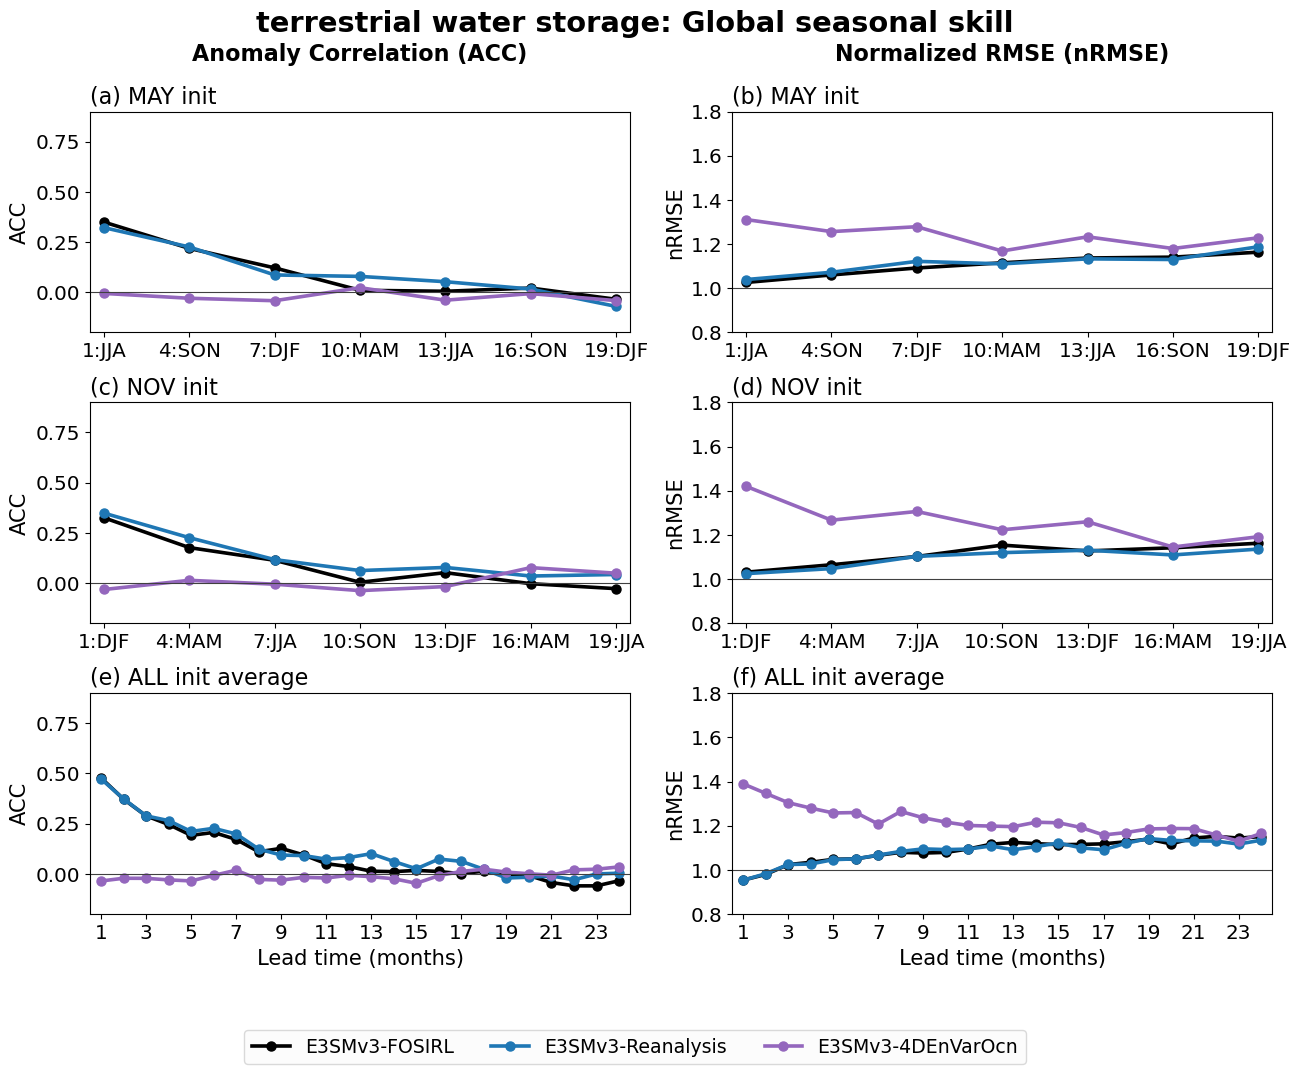

Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/e3sm-s2d_diag/fig_regional_acc_nrmse_lnd_tws_land.png


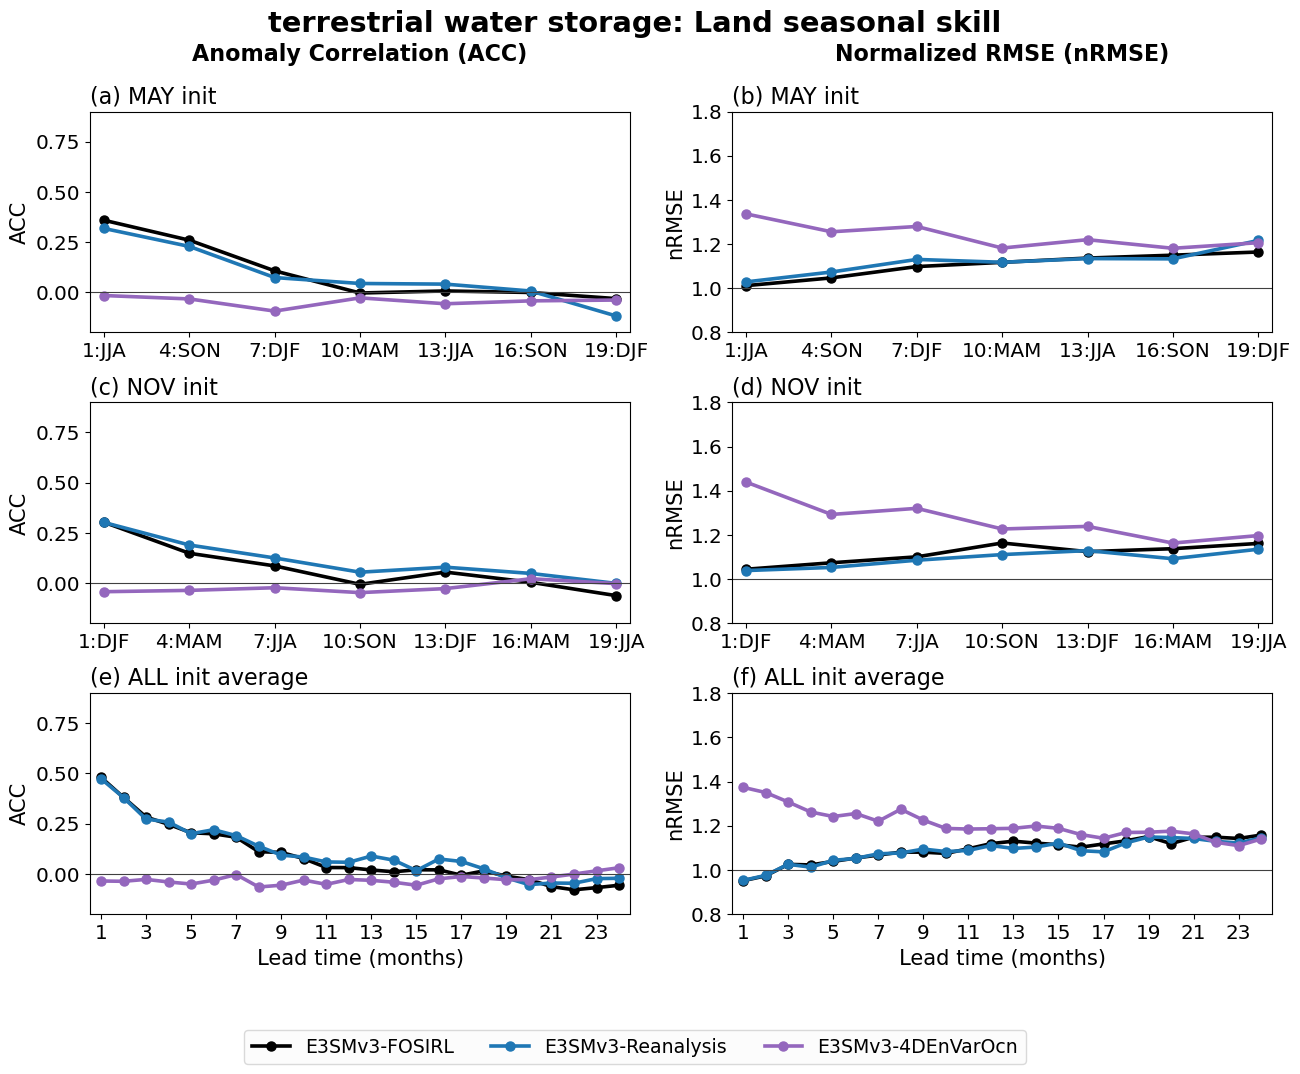

Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/e3sm-s2d_diag/fig_regional_acc_nrmse_lnd_tws_tropics.png


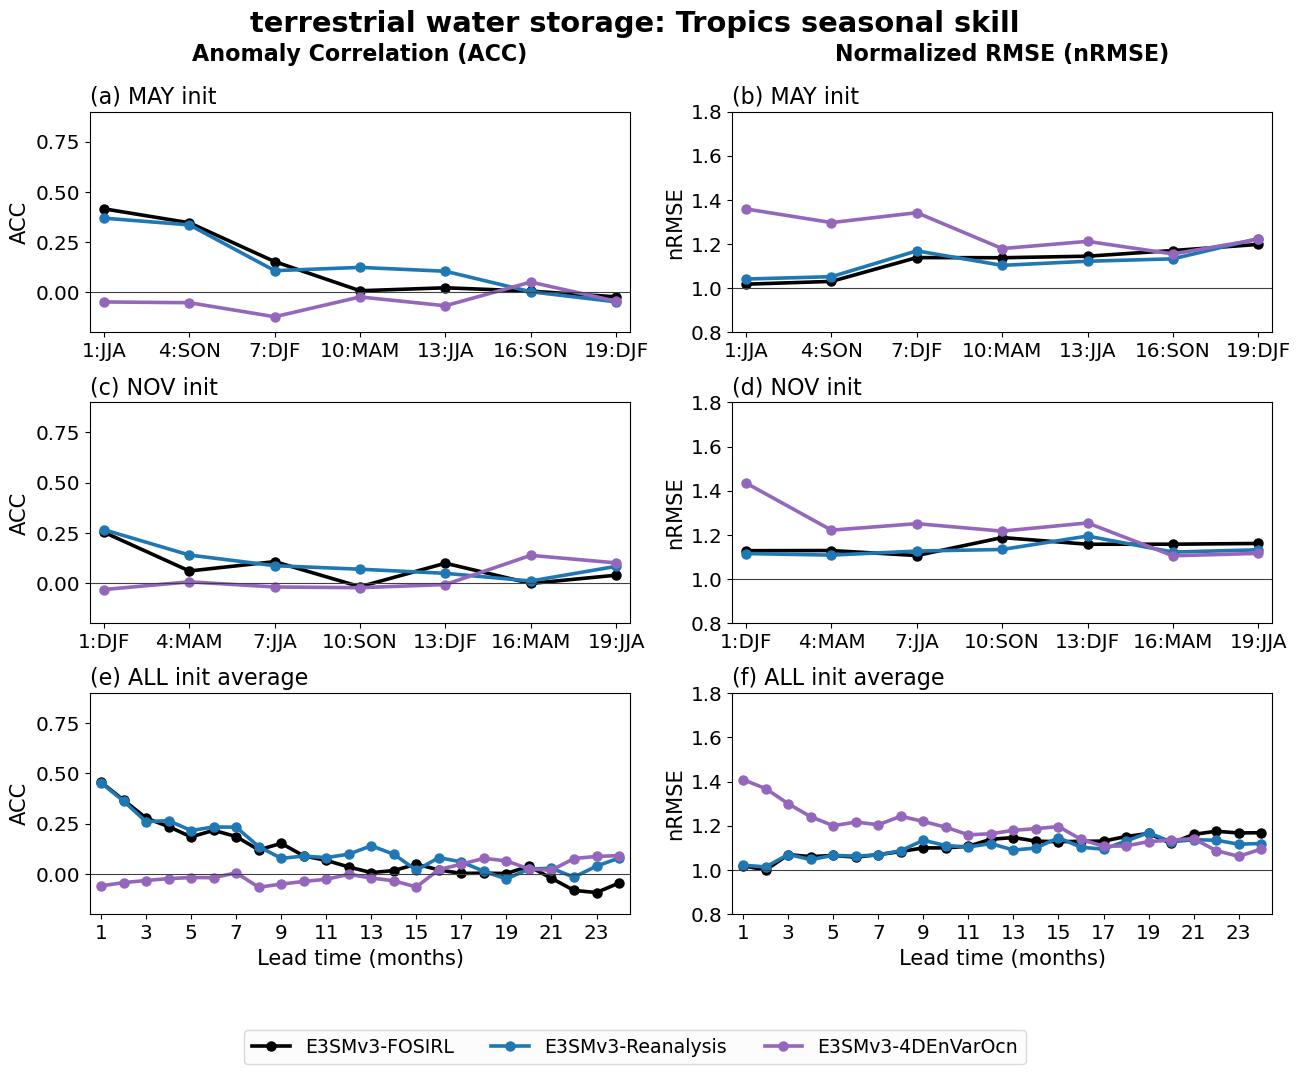

Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/e3sm-s2d_diag/fig_regional_acc_nrmse_lnd_tws_nhex.png


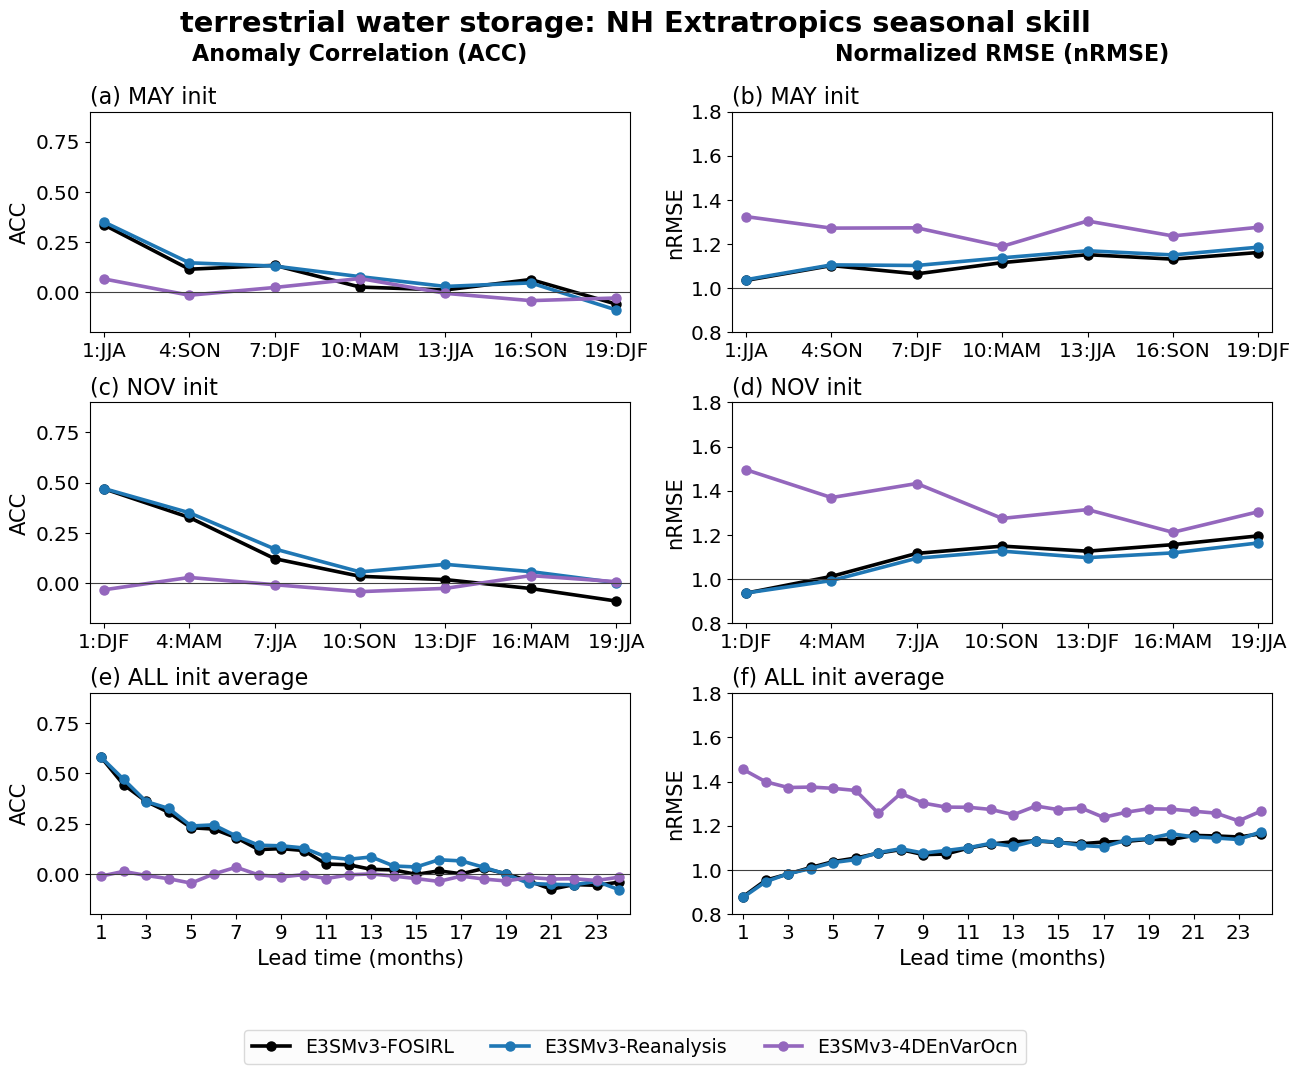

Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/e3sm-s2d_diag/fig_regional_acc_nrmse_lnd_tws_shex.png


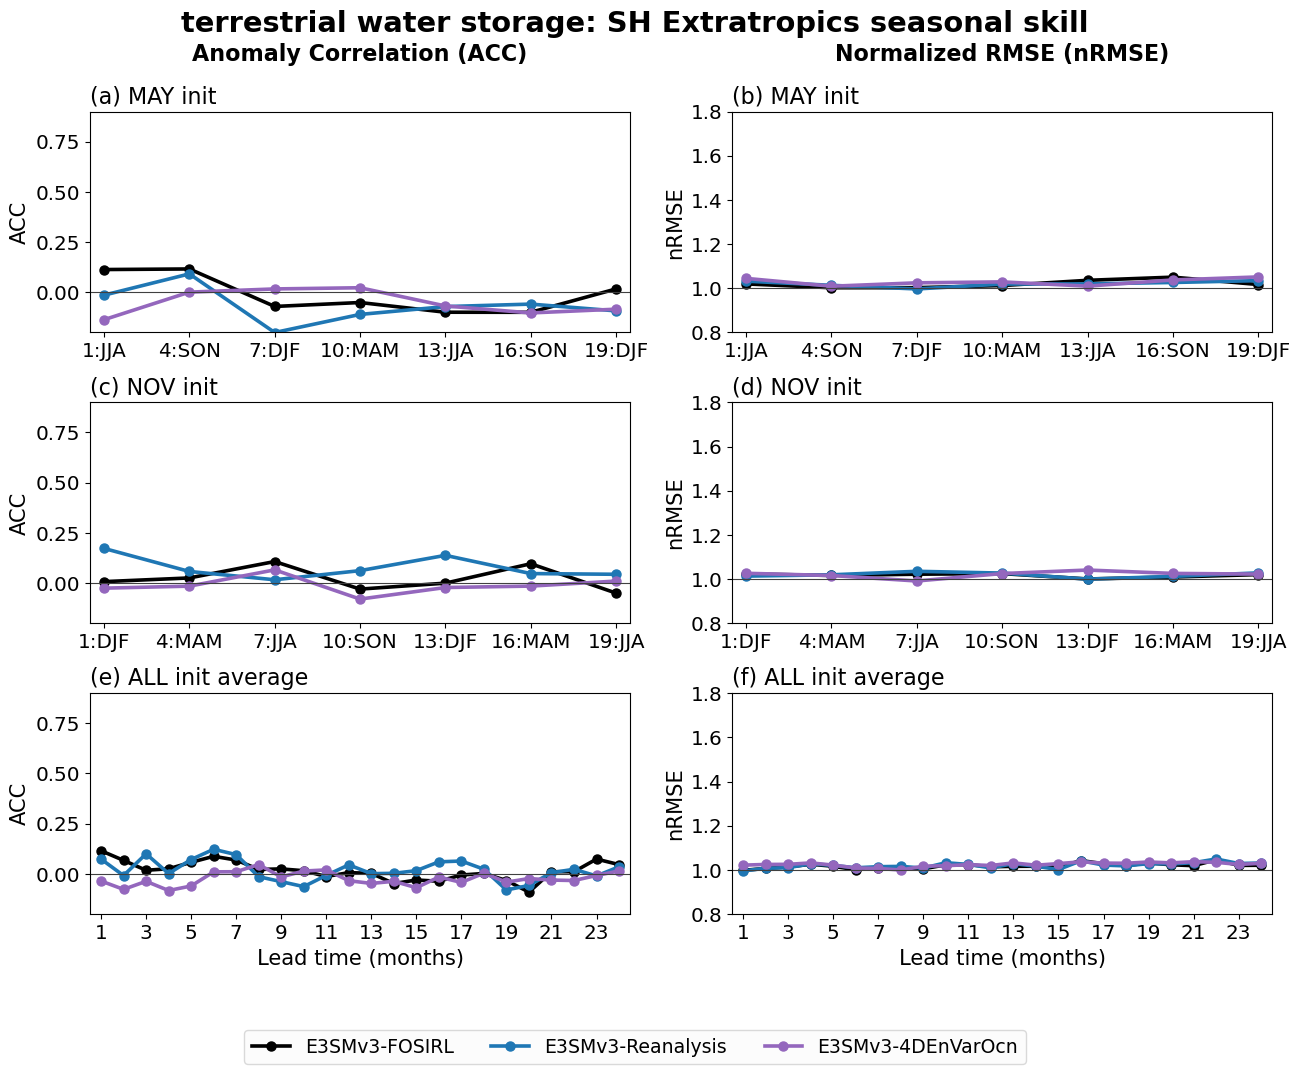

Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/e3sm-s2d_diag/fig_regional_acc_nrmse_lnd_tws_conus.png


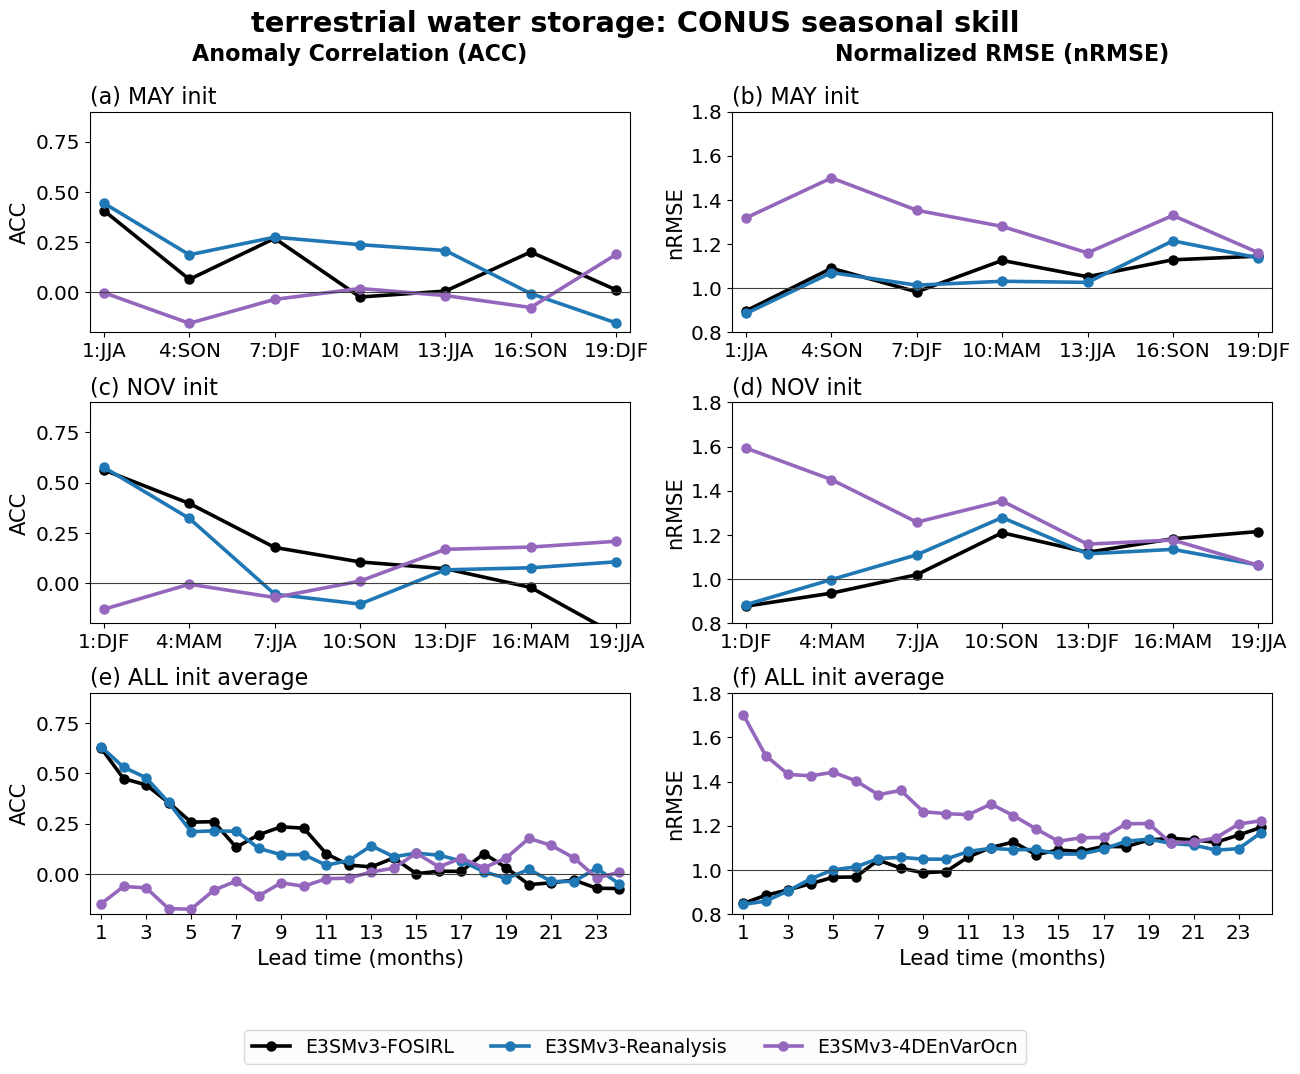

Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/e3sm-s2d_diag/fig_regional_acc_nrmse_lnd_tws_na_box.png


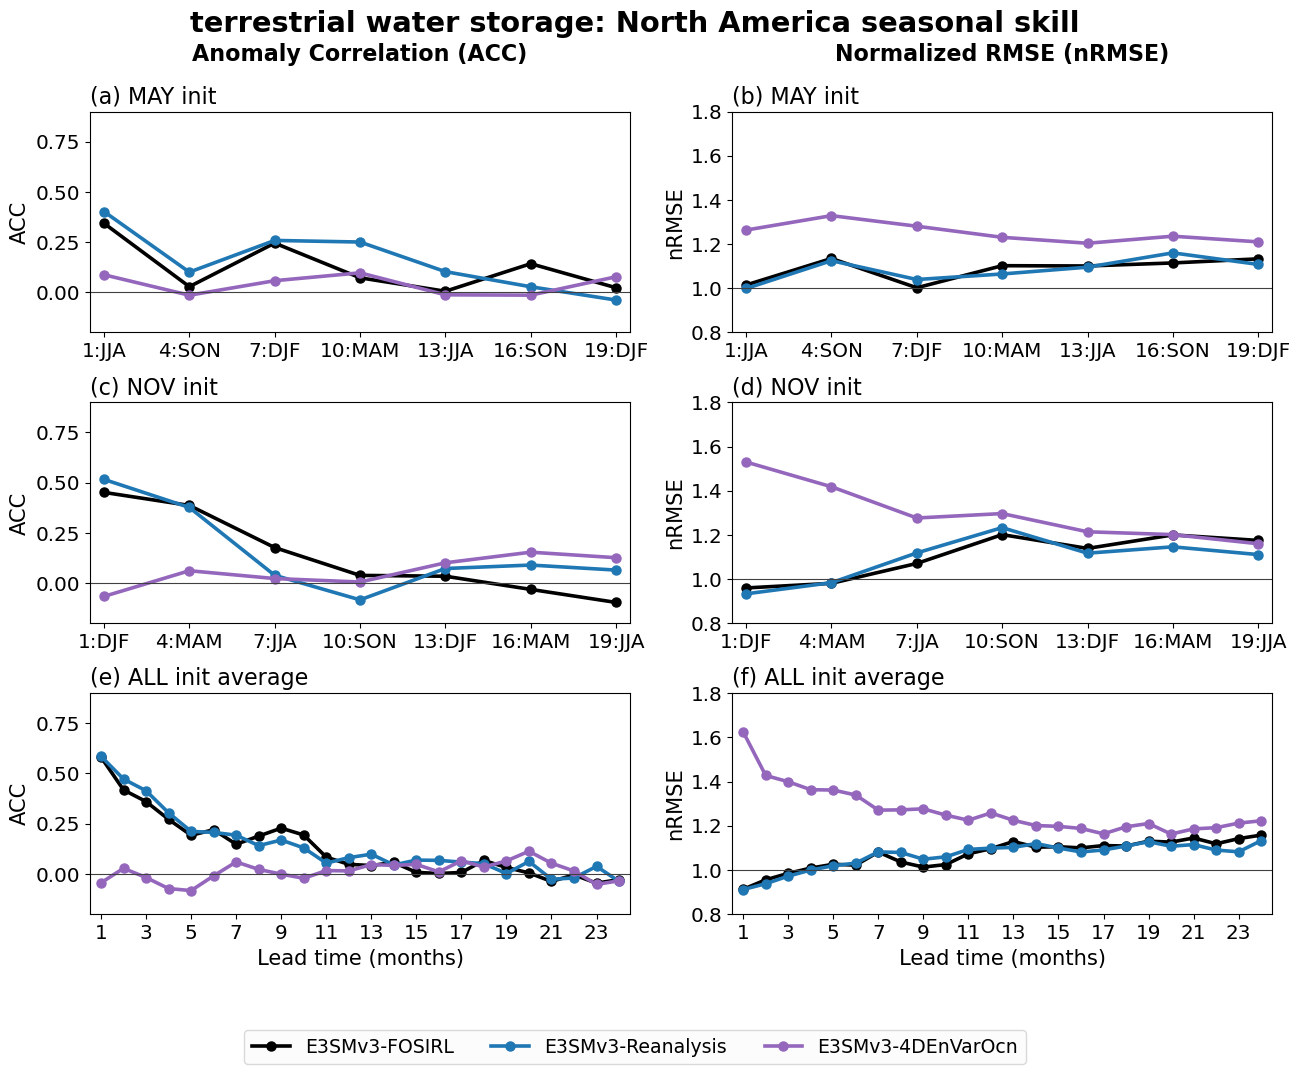

Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/e3sm-s2d_diag/fig_regional_acc_nrmse_lnd_tws_eurasia_box.png


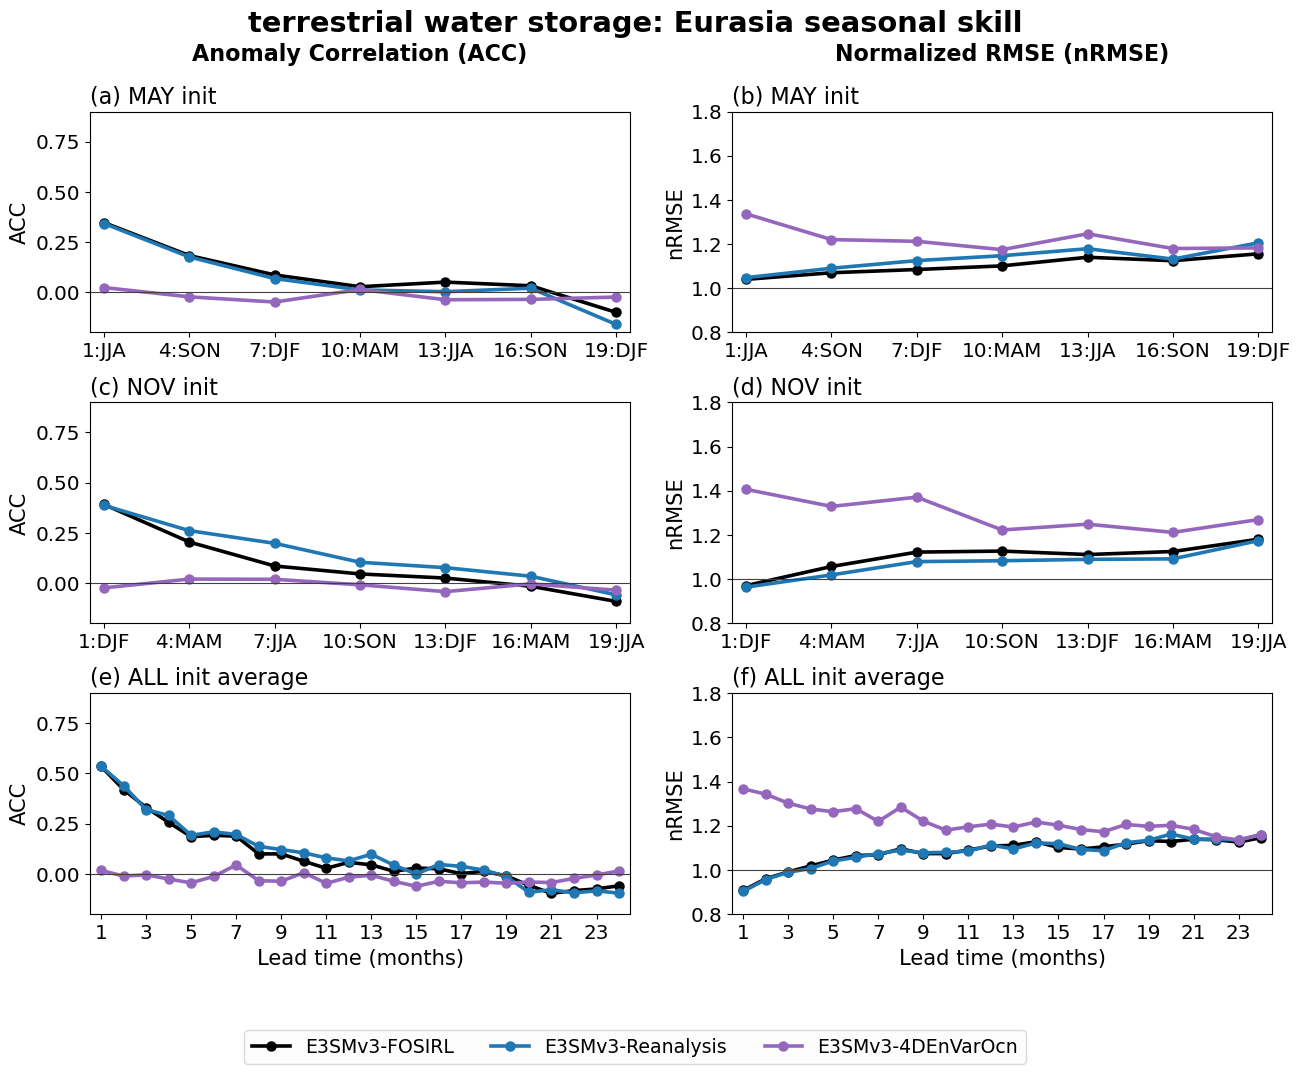

Closed workflow Dask resources.


In [35]:
for job in JOBS:
    realm, field = job['realm'], job['field']
    paths = resolve_skill_files(job['source_tags'], realm, field)
    monthly_paths = resolve_monthly_skill_files(job['source_tags'], realm, field)
    print(f'Using {realm}/{field} skill products:')
    for key, path in paths.items():
        print(f'  {key}: {path}')

    # Re-key with (model, initialization month), then summarize both cached
    # gridded metrics.  `rmse` in the 1a ACC notebooks is normalized RMSE.
    skills_by_case_month = {key: load_netcdf(path) for key, path in paths.items()}
    regional_metrics = {
        key: regional_skill_metrics(skill, REGIONAL_REGIONS)
        for key, skill in skills_by_case_month.items()
    }
    monthly_skills_by_case_month = {key: load_netcdf(path) for key, path in monthly_paths.items()}
    monthly_regional_metrics = {
        key: regional_skill_metrics(skill, REGIONAL_REGIONS)
        for key, skill in monthly_skills_by_case_month.items()
    }

    for region in PLOT_REGIONS:
        region_label = REGION_LABELS[region]
        diagnostic_title = f'{SETUP["label"]}: {region_label} seasonal skill'
        figure, _ = plot_regional_acc_skill_template(
            regional_metrics, monthly_skills_by_case_month=monthly_regional_metrics,
            region=region, title=diagnostic_title, **FIGURE_PARAMS,
            acc_ylim=SETUP['acc_ylim'], nrmse_ylim=SETUP['nrmse_ylim'],
            case_styles=CASE_STYLES, season_labels=SEASON_LABELS,
            init_labels=INIT_LABELS,
            lead_offset=SEASONAL_LEAD_OFFSET, lead_xlabel=LEAD_XLABEL,
        )
        region_token = region.lower().replace(' ', '_')
        output = FIGURE_OUTDIR / f'fig_regional_acc_nrmse_{realm}_{field.lower()}_{region_token}.png'
        mov.save_figure(
            figure, output, mode='', metric='regional_acc_nrmse_skill', title=diagnostic_title,
            caption=('Three-row regional ACC/nRMSE layout. MAY/NOV use seasonal skill; '
                     'the all-init row averages true monthly L=1..24 skill products.'),
            dpi=300,
        )
        print('Saved figure:', output)
        plt.show()

# Release Dask resources on normal completion.
close_notebook_resources(globals())
print("Closed workflow Dask resources.")
